# Benchmark Es4A vs Es4B (TrainStations)
Questo notebook compila i file C `es4A.c` e `es4B.c`, genera casi di test con $L = 1000000$ (1 milione) e confronta i tempi di esecuzione per validare le complessità teoriche $O(L + 2^N)$ e $O(M \log L)$.

In [9]:
import subprocess
import time
import random
import matplotlib.pyplot as plt

# Compilazione dei due eseguibili
print('Compilazione in corso...')
subprocess.run(['gcc', '-O2', 'es4A.c', '-o', 'es4A'])
subprocess.run(['gcc', '-O2', 'es4B.c', '-o', 'es4B'])
print('Compilazione completata.')

Compilazione in corso...


es4A.c: In function ‘main’:
es4A.c:90:5: warning: ignoring return value of ‘scanf’ declared with attribute ‘warn_unused_result’ [-Wunused-result]
   90 |     scanf("%d %d %d %d", &L, &N, &M, &controllo);
      |     ^~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
es4A.c:103:9: warning: ignoring return value of ‘scanf’ declared with attribute ‘warn_unused_result’ [-Wunused-result]
  103 |         scanf("%d", &s);
      |         ^~~~~~~~~~~~~~~


Compilazione completata.


es4B.c: In function ‘main’:
es4B.c:129:5: warning: ignoring return value of ‘scanf’ declared with attribute ‘warn_unused_result’ [-Wunused-result]
  129 |     scanf("%d %d %d %d", &L, &N, &M, &controllo);
      |     ^~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
es4B.c:142:9: warning: ignoring return value of ‘scanf’ declared with attribute ‘warn_unused_result’ [-Wunused-result]
  142 |         scanf("%d", &s);
      |         ^~~~~~~~~~~~~~~


In [10]:
def generate_test_case(L, N, M, spacing_max=None):
    controllo = random.randint(1, L - 1)
    stations = {controllo}

    if spacing_max is None:
        while len(stations) < N:
            stations.add(random.randint(1, L - 1))
    else:
        # Costruisce una nuvola di stazioni attorno a controllo con gap variabili.
        positions = [controllo]
        left = controllo
        right = controllo

        while len(positions) < N:
            gap = random.randint(1, spacing_max)
            if random.random() < 0.5 and left > 1:
                left = max(1, left - gap)
                positions.append(left)
            elif right < L - 1:
                right = min(L - 1, right + gap)
                positions.append(right)
            else:
                positions.append(random.randint(1, L - 1))

        stations = set(positions)
        while len(stations) < N:
            stations.add(random.randint(1, L - 1))

    input_data = f"{L} {N} {M} {controllo}\n"
    for s in sorted(stations):
        input_data += f"{s}\n"
    return input_data


def run_test(executable, input_data, timeout_sec=3600):
    start = time.time()
    try:
        # Timeout applicato per prevenire il blocco della soluzione A (esponenziale)
        subprocess.run(['./' + executable], input=input_data.encode(), capture_output=True, timeout=timeout_sec)
        end = time.time()
        return end - start
    except subprocess.TimeoutExpired:
        return None  # Indica che ha sforato il limite di tempo

In [11]:
L = 1000000
# Per la soluzione A (esponenziale O(2^N)), N deve rimanere relativamente basso (es. <= 30)
# La soluzione B può scalare senza problemi, ma qui cerchiamo di graficare il punto di rottura di A.
N_values = range(2,33,3) 
M_ratio = 0.4  # Rimuoviamo il 40% delle stazioni

times_A = []
times_B = []
valid_N = []

print(f"Avvio test con L = {L}\n")
for N in N_values:
    M = int(N * M_ratio)
    input_data = generate_test_case(L, N, M)
    
    t_A = run_test('es4A', input_data, timeout_sec=3600)
    t_B = run_test('es4B', input_data, timeout_sec=3600)
    
    if t_A is not None:
        times_A.append(t_A)
        print(f"N={N:2d}, M={M:2d} -> es4A: {t_A:.4f}s")
    else:
        times_A.append(None)
        print(f"N={N:2d}, M={M:2d} -> es4A: TIMEOUT (> 5.0s)")
        
    if t_B is not None:
        times_B.append(t_B)
        print(f"            -> es4B: {t_B:.4f}s")
    else:
        times_B.append(None)
        print(f"            -> es4B: TIMEOUT")
        
    valid_N.append(N)
    print("-" * 40)

Avvio test con L = 1000000

N= 2, M= 0 -> es4A: 0.0115s
            -> es4B: 0.0134s
----------------------------------------
N= 5, M= 2 -> es4A: 0.0086s
            -> es4B: 0.0129s
----------------------------------------
N= 8, M= 3 -> es4A: 0.0089s
            -> es4B: 0.0188s
----------------------------------------
N=11, M= 4 -> es4A: 0.0106s
            -> es4B: 0.0097s
----------------------------------------
N=14, M= 5 -> es4A: 0.0251s
            -> es4B: 0.0120s
----------------------------------------
N=17, M= 6 -> es4A: 0.0968s
            -> es4B: 0.0103s
----------------------------------------
N=20, M= 8 -> es4A: 1.0825s
            -> es4B: 0.0103s
----------------------------------------
N=23, M= 9 -> es4A: 7.3673s
            -> es4B: 0.0092s
----------------------------------------


KeyboardInterrupt: 

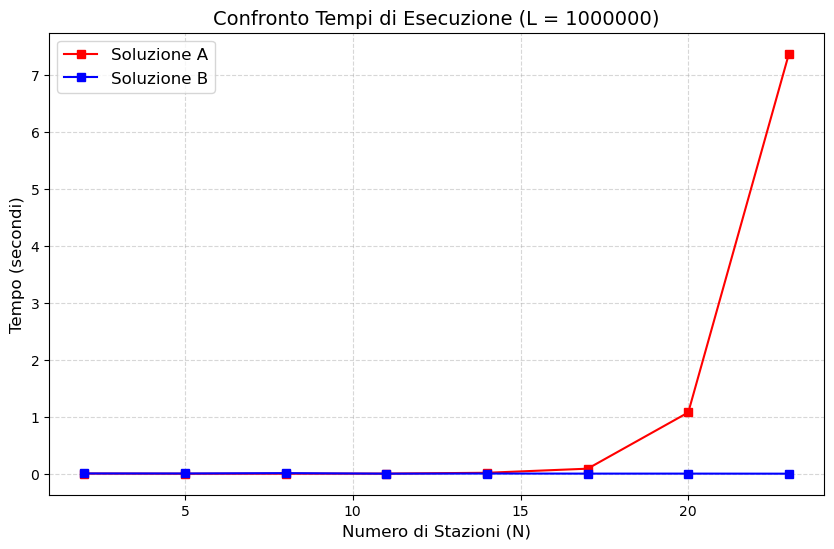

In [12]:
plt.figure(figsize=(10, 6))

# Filtra i valori validi per il plot della soluzione A
A_N = [n for n, t in zip(valid_N, times_A) if t is not None]
A_T = [t for t in times_A if t is not None]

plt.plot(A_N, A_T, label='Soluzione A', marker='s', color='red')
plt.plot(valid_N, times_B, label='Soluzione B', marker='s', color='blue')

plt.title(f'Confronto Tempi di Esecuzione (L = {L})', fontsize=14)
plt.xlabel('Numero di Stazioni (N)', fontsize=12)
plt.ylabel('Tempo (secondi)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

Compilazione finale di es4B in corso...


es4B.c: In function ‘main’:
es4B.c:131:5: warning: ignoring return value of ‘scanf’ declared with attribute ‘warn_unused_result’ [-Wunused-result]
  131 |     scanf("%ld %d %d %ld", &L, &N, &M, &controllo);
      |     ^~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
es4B.c:144:9: warning: ignoring return value of ‘scanf’ declared with attribute ‘warn_unused_result’ [-Wunused-result]
  144 |         scanf("%ld", &s);
      |         ^~~~~~~~~~~~~~~~


L= 12000000000, N= 150000, M=  75000, spacing_max=   20000 -> 27.061 s, returncode=0
L= 11000000000, N= 150000, M=  75000, spacing_max=   18333 -> 27.685 s, returncode=0
L= 10500000000, N= 150000, M=  75000, spacing_max=   17500 -> 23.367 s, returncode=0
L= 10000000000, N= 150000, M=  75000, spacing_max=   16666 -> 18.020 s, returncode=0
L=  9500000000, N= 150000, M=  75000, spacing_max=   15833 -> 21.247 s, returncode=0
L=  9000000000, N= 150000, M=  75000, spacing_max=   15000 -> 32.066 s, returncode=0
L=  8500000000, N= 150000, M=  75000, spacing_max=   14166 -> 17.185 s, returncode=0
L=  8000000000, N= 150000, M=  75000, spacing_max=   13333 -> 17.479 s, returncode=0
L=  7500000000, N= 150000, M=  75000, spacing_max=   12500 -> 13.896 s, returncode=0
L=  7000000000, N= 150000, M=  75000, spacing_max=   11666 -> 18.289 s, returncode=0
L=  6500000000, N= 150000, M=  75000, spacing_max=   10833 -> 11.140 s, returncode=0
L=  6000000000, N= 150000, M=  75000, spacing_max=   10000 -> 16.

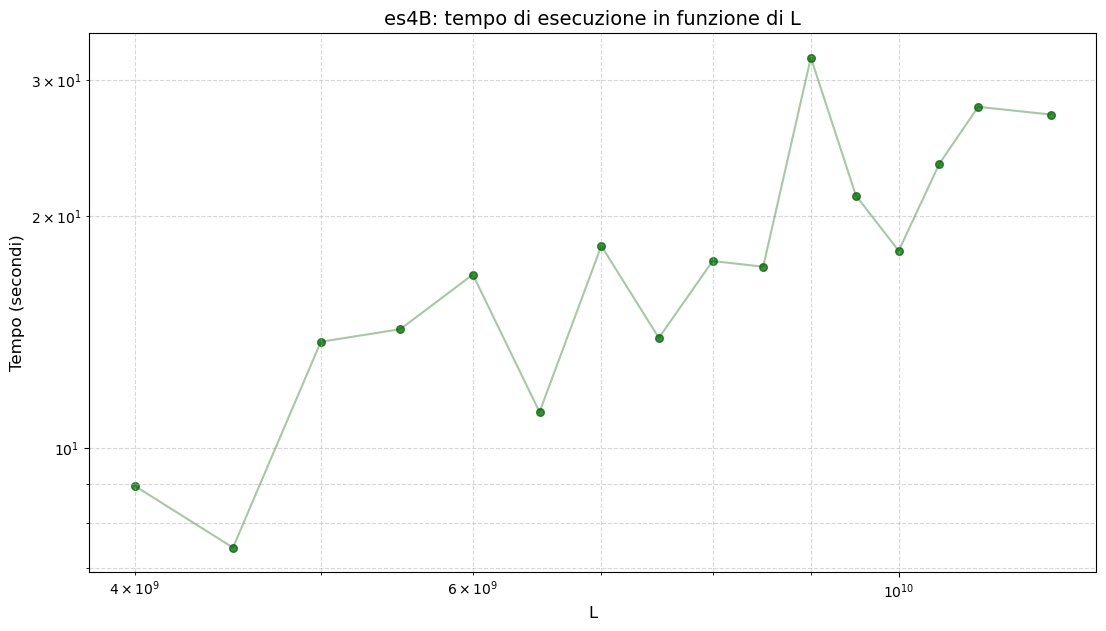

In [20]:
# Grafico finale di es4B: un solo test per punto, tanti punti distinti, niente ripetizioni
import subprocess, time, random, matplotlib.pyplot as plt

# L parte oltre 10^10 e gli altri punti scendono gradualmente ma restano molto alti
L_values = [12_000_000_000, 11_000_000_000, 10_500_000_000, 10_000_000_000, 9_500_000_000, 9_000_000_000, 8_500_000_000, 8_000_000_000, 7_500_000_000, 7_000_000_000, 6_500_000_000, 6_000_000_000, 5_500_000_000, 5_000_000_000, 4_500_000_000, 4_000_000_000]
results = []

print('Compilazione finale di es4B in corso...')
subprocess.run(['gcc', '-O2', 'es4B.c', '-o', 'es4B'])

for L in L_values:
    # Un solo caso per ogni L, con N e M molto grandi ma proporzionati
    N = min(300_000, max(150_000, L // 80_000))
    M = max(1, N // 2)
    spacing_max = max(1_000, min(1_000_000, L // max(N, 1) // 4))
    input_data = generate_test_case(L, N, M, spacing_max=spacing_max)

    start = time.time()
    try:
        p = subprocess.run(['./es4B'], input=input_data.encode(), capture_output=True, timeout=3600)
        elapsed = time.time() - start
        results.append((L, elapsed))
        print(f'L={L:>12}, N={N:>7}, M={M:>7}, spacing_max={spacing_max:>8} -> {elapsed:.3f} s, returncode={p.returncode}')
    except subprocess.TimeoutExpired:
        print(f'L={L:>12}, N={N:>7}, M={M:>7}, spacing_max={spacing_max:>8} -> TIMEOUT after 3600 s')

plot_L = [l for l, t in results]
plot_times = [t for _, t in results]

plt.figure(figsize=(13, 7))
plt.scatter(plot_L, plot_times, s=30, color='darkgreen', alpha=0.75)
plt.plot(plot_L, plot_times, color='darkgreen', alpha=0.35, linewidth=1.5)
plt.xscale('log')
plt.yscale('log')
plt.title('es4B: tempo di esecuzione in funzione di L', fontsize=14)
plt.xlabel('L', fontsize=12)
plt.ylabel('Tempo (secondi)', fontsize=12)
plt.grid(True, which='both', ls='--', alpha=0.5)
plt.show()

In [ ]:
# Test ESAGERATI GIGANTI su es4B: L = 1 miliardo, 2 miliardi, 3 miliardi
import subprocess, time, random, matplotlib.pyplot as plt

# Valori enormi di L, vicino ai limiti reali ora che abbiamo fixato i tipi
L_values_giant = [1_000_000_000, 1_500_000_000, 2_000_000_000]
results_giant = []

print('Test GIGANTI su es4B in corso...')
subprocess.run(['gcc', '-O2', 'es4B.c', '-o', 'es4B'])

for L in L_values_giant:
    # N e M proporzionati al valore enorme di L
    N = min(200_000, max(100_000, L // 20_000))
    M = max(1, N // 2)
    spacing_max = max(500, min(300_000, L // max(N, 1) // 5))
    input_data = generate_test_case(L, N, M, spacing_max=spacing_max)

    start = time.time()
    try:
        p = subprocess.run(['./es4B'], input=input_data.encode(), capture_output=True, timeout=7200)
        elapsed = time.time() - start
        results_giant.append((L, elapsed))
        print(f'L={L:>12}, N={N:>7}, M={M:>7}, spacing_max={spacing_max:>8} -> {elapsed:.3f} s, returncode={p.returncode}')
    except subprocess.TimeoutExpired:
        print(f'L={L:>12}, N={N:>7}, M={M:>7}, spacing_max={spacing_max:>8} -> TIMEOUT after 7200 s')

plot_L_giant = [l for l, t in results_giant]
plot_times_giant = [t for _, t in results_giant]

plt.figure(figsize=(10, 6))
plt.scatter(plot_L_giant, plot_times_giant, s=50, color='darkred', alpha=0.8)
plt.plot(plot_L_giant, plot_times_giant, color='darkred', alpha=0.4, linewidth=2)
plt.xscale('log')
plt.yscale('log')
plt.title('es4B: Test GIGANTI - tempo di esecuzione per L enorme', fontsize=14)
plt.xlabel('L', fontsize=12)
plt.ylabel('Tempo (secondi)', fontsize=12)
plt.grid(True, which='both', ls='--', alpha=0.5)
plt.show()